

# Ventilator Pressure Prediction

[https://www.kaggle.com/competitions/ventilator-pressure-prediction](https://www.kaggle.com/competitions/ventilator-pressure-prediction)

---

# 1. Introduction

## 1.1 Background

Mechanical ventilation is a critical medical intervention used when patients are unable to breathe adequately on their own. A ventilator delivers oxygen into the patient's lungs through a tube inserted into the windpipe while the patient is sedated.

Mechanical ventilation is a highly clinician-intensive process. This limitation became particularly visible during the early stages of the COVID-19 pandemic when the demand for ventilators and trained medical staff increased dramatically worldwide.

Developing and testing new ventilator control strategies is costly and complex, especially before reaching clinical trial stages. High-fidelity computational simulators provide a promising solution by enabling safe and cost-effective experimentation.

---

## 1.2 Problem Statement

Traditional ventilator control systems rely on **PID (Proportional–Integral–Derivative) controllers**.

Although PID controllers are widely used, they may struggle to adapt to patients with significantly different lung characteristics.

Existing ventilator simulators are often trained as **ensembles of models**, each corresponding to a specific lung configuration. However, lung mechanics vary continuously across patients.

Therefore, a more general **parametric modeling approach** is required.

---

## 1.3 Research Objective

The objective of this project is to develop a **data-driven simulator** capable of predicting airway pressure dynamics during mechanical ventilation.

The model must account for:

* **Control inputs** from ventilator valves
* **Lung mechanical properties**
* **Temporal airflow dynamics**

The central hypothesis is that:

> Deep learning models can better generalize across lungs with varying resistance and compliance compared to traditional PID controllers.

---

# 2. Ventilator System Overview

## 2.1 Experimental Setup

The dataset was generated using a **modified open-source ventilator** connected to an artificial **bellows test lung**.

The ventilator system includes:

* **Two control signals**
* **One target variable (airway pressure)**

The ventilator manipulates airflow using inspiratory and expiratory valves.

---

## 2.2 Control Inputs

### Inspiratory Valve (`u_in`)

Continuous variable ranging from **0 to 100** representing the percentage opening of the inspiratory valve.

| Value | Meaning          |
| ----- | ---------------- |
| 0     | Valve closed     |
| 100   | Valve fully open |

---

### Expiratory Valve (`u_out`)

Binary variable indicating whether the expiratory valve is open.

| Value | Meaning      |
| ----- | ------------ |
| 0     | Valve closed |
| 1     | Valve open   |

---

## 2.3 Target Variable

### Airway Pressure (`pressure`)

Measured airway pressure inside the respiratory circuit.

Units: **cmH₂O**

The goal of the model is to predict this pressure at every timestep.

---

# 3. Dataset Description

## 3.1 Time Series Structure

Each breathing cycle corresponds to **one time series sequence**.

Dataset characteristics:

| Property        | Value                            |
| --------------- | -------------------------------- |
| Sequence length | 80 timesteps                     |
| Duration        | ~3 seconds                       |
| Target          | airway pressure                  |
| Inputs          | valve controls + lung parameters |

Each sequence corresponds to **one breath** identified by `breath_id`.

---

## 3.2 Dataset Columns

### Identifiers

| Feature     | Description                                          |
| ----------- | ---------------------------------------------------- |
| `id`        | unique identifier for each timestep                  |
| `breath_id` | identifier grouping timesteps within the same breath |

---

### Lung Mechanical Properties

| Feature | Meaning         |
| ------- | --------------- |
| `R`     | lung resistance |
| `C`     | lung compliance |

These parameters define the physical behavior of the lung.

Higher resistance makes airflow more difficult, while higher compliance allows the lung to expand more easily.

---

### Control Signals

| Feature | Meaning                   |
| ------- | ------------------------- |
| `u_in`  | inspiratory valve opening |
| `u_out` | expiratory valve state    |

---

### Time Variable

| Feature     | Meaning                     |
| ----------- | --------------------------- |
| `time_step` | timestamp within the breath |

---

# 4. Ventilator Physics

The pressure dynamics inside the lung can be approximated by the equation:

[
P(t) = R \cdot F(t) + \frac{V(t)}{C}
]

where:

| Symbol | Meaning         |
| ------ | --------------- |
| (P(t)) | airway pressure |
| (F(t)) | airflow         |
| (V(t)) | lung volume     |
| (R)    | lung resistance |
| (C)    | lung compliance |

The dataset provides airflow and valve signals, and the goal is to learn a model that approximates this underlying physiological relationship.

---

# 5. Time Series Modeling

## 5.1 Time Series Characteristics

A time series is a sequence of observations ordered in time:

[
x_1, x_2, x_3, ..., x_T
]

Time series differ from traditional tabular data because observations exhibit **temporal dependencies**.

Key characteristics include:

* Autocorrelation
* Sequential structure
* Dynamic evolution

---

## 5.2 Time Series in Ventilator Data

In this dataset:

* Each breath forms a **short multivariate time series**
* Sequences are independent across breaths
* Within each breath, pressure evolves dynamically

Pressure depends on:

* Previous pressure values
* Airflow inputs
* Lung mechanical properties

Therefore, the ventilator system behaves as a **nonlinear dynamical system**.

---

# 6. Feature Engineering

Feature engineering aims to provide the model with **temporal context and physical signals** describing airflow dynamics.

The engineered features capture:

* airflow accumulation
* breathing phase transitions
* past and future airflow patterns

These signals help the model approximate the **underlying respiratory mechanics**.

*(your feature engineering section can follow here)*

---

# 7. Model Architecture

Sequential models are particularly suitable for this problem because they capture **temporal dependencies**.

Common architectures for this task include:

* Recurrent Neural Networks (RNN)
* Long Short-Term Memory (LSTM)
* Gated Recurrent Units (GRU)
* Transformer architectures

These models can learn nonlinear relationships between airflow control signals and airway pressure.

---

# 8. Evaluation Metric

Model performance is evaluated using **Mean Absolute Error (MAE)** during the inspiratory phase.

[
MAE = \frac{1}{N} \sum |y_i - \hat{y}_i|
]

Only timesteps where `u_out = 0` (inhalation phase) contribute to the score.

MAE measures the **average magnitude of prediction errors** in the same units as airway pressure.

---

# 9. Model Interpretability

To understand model behavior, we apply **SHAP (SHapley Additive Explanations)**.

SHAP assigns each feature a contribution value explaining its impact on a prediction.

A prediction can be decomposed as:

[
f(x) = \phi_0 + \sum_{i=1}^{d} \phi_i
]

where ( \phi_i ) represents the contribution of feature (i).

This allows analysis of:

* global feature importance
* local explanations for individual breaths
* temporal importance across timesteps

---

# 10. Conclusion

This project formulates ventilator simulation as a **multivariate time-series prediction problem**.

By combining:

* physics-inspired features
* sequential deep learning models
* interpretability techniques

the system aims to accurately model airway pressure dynamics across different lung configurations.

Such models may support the development of **adaptive ventilator control systems** capable of improving respiratory care.

---



# IMPORTS

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import time
import warnings
import gc
import multiprocessing
import os,random, math, psutil, pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#              sklearn
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, normalize
from sklearn.model_selection import train_test_split, GroupKFold, KFold
import tensorflow as tf
! conda env export > environment.yml

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#              Keras
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
import tensorflow.keras.backend as K
from tensorflow.keras.losses import MeanSquaredError as mse_loss
from tensorflow.keras.utils import *
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras import regularizers

from tensorflow.keras.layers import Dense, LSTM ,Bidirectional
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

import shap
import numpy as np

__COLAB__=False


2026-03-11 10:33:55.037102: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/bin/bash: /home/gpaolo/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)


/home/gpaolo/miniconda3/envs/dl_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set Notebook Options

In [2]:

print("Tensorflow version " + tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

Tensorflow version 2.20.0
Num GPUs Available:  1


# Functions

## ADD FEATURES
This function creates engineered features for the ventilator time-series dataset, where each breath_id represents a single breathing cycle and each row corresponds to a time step within that breath.

The dataset represents ventilator breathing cycles.
Each breath_id corresponds to a complete breath and contains multiple time steps describing airflow and valve behavior.

The goal of feature engineering is to provide the model with information about: 
- Airflow dynamics  
- Accumulated lung volume  
- Breathing phase transitions  
- Physical lung properties 

These signals help the model predict airway pressure at each time step.

Since the dataset provides airflow (u_in) and valve state (u_out), we engineer features that approximate:
- Flow history
- Accumulated volume
- Breathing phase
- Lung mechanical properties


--
**Volume / Accumulation Features**  
These features approximate the amount of air delivered to the lungs over time.
Pressure increases as lung volume increases, so cumulative airflow helps estimate how full the lungs are during a breath.
|Feature	    |    Meaning  
|---------------|-------------------------------------
|`u_in`   |airflow entering the lungs | 
|`time_step`   |time  |

Meaning  
This approximates the integral of airflow over time.  
It estimates the volume of air delivered during the breath so far.  
This is important because pressure depends on lung volume. 

**Cumulative air-flow**
 
Pressure in lungs increases as volume increases.  
|Feature	    |    Meaning  
|---------------|-------------------------------------|
|`u_in_cumsum`	| Running total of airflow entering during the breath. |



**Lag Features (Past Information)**  
Pressure depends on previous airflow because lungs have memory.  
|Feature	    |    Meaning  
|---------------|-------------------------------------|
|`u_in_lag1`	| airflow at **previous timestep**    |
|`u_out_lag1`	| valve state at **previous timestep**|  
|`u_in_lag2`	| airflow **2 timesteps ago**         |
|`u_in_lag3`	| airflow **3 timesteps ago**         |
|`u_in_lag4`	| airflow **4 timesteps ago**         |

**Forward Lag (Future Information)**
For models trained on entire sequences, future values help capture patterns in the breathing curve.
A sudden drop in airflow indicates exhalation phase starting.  

|Feature	    |    Meaning  
|---------------|-------------------------------------|
| `u_in_lag_back1` | Airflow at the **next timestep** |
| `u_in_lag_back2` | Airflow **two timesteps ahead**  |
| `u_in_lag_back3` | Airflow **three timesteps ahead** |
| `u_in_lag_back4` | Airflow **four timesteps ahead**  |



**Past Valve State (u_out)**
The variable `u_out` indicates whether the exhalation valve is open.
Past valve states help detect the breathing phase transition between inhalation and exhalation.
Past and future exhalation valve states.


|Feature	    |    Meaning  
|---------------|-------------------------------------|
|`u_out_lag1`	|Valve state 1 timestep before|
|`u_out_lag2`	|Valve state 2 timesteps before|
|`u_out_lag3`	|Valve state 3 timesteps before|
|`u_out_lag4`	| state 4 timesteps before|


**Future Valve State**

Future valve information helps anticipate when exhalation will begin, which typically causes a rapid pressure decrease.
|Feature	    |    Meaning  
|---------------|-------------------------------------|
|`u_out_lag_back1`	|Valve state next timestep|
|`u_out_lag_back2`	|Valve state two timesteps ahead|
|`u_out_lag_back3`	|Valve state three timesteps ahead|
|`u_out_lag_back4`	|Valve state four timesteps ahead|


**Lung Mechanical Properties**
These parameters define the physical properties of the lung and strongly influence pressure behavior.

|Feature	    |    Meaning  
|---------------|-------------------------------------|
|`R`	|Lung resistance affecting pressure from airflow|
|`C`	|Lung compliance affecting pressure from lung volume|
|`R__C`	|Combined lung type formed from R and C|



In [3]:

# # Functions
#from google.colab import drive
#drive.mount('/content/gdrive', force_remount=True)
#!ls "/content/gdrive/My Drive/kaggle"
def add_features(df):#022
    df['area'] = df['time_step'] * df['u_in']
    df['area'] = df.groupby('breath_id')['area'].cumsum()
    df['u_in_cumsum'] = (df['u_in']).groupby(df['breath_id']).cumsum()
    df['u_in_lag1'] = df.groupby('breath_id')['u_in'].shift(1)
    df['u_out_lag1'] = df.groupby('breath_id')['u_out'].shift(1)
    df['u_in_lag_back1'] = df.groupby('breath_id')['u_in'].shift(-1)
    df['u_out_lag_back1'] = df.groupby('breath_id')['u_out'].shift(-1)
    df['u_in_lag2'] = df.groupby('breath_id')['u_in'].shift(2)
    df['u_out_lag2'] = df.groupby('breath_id')['u_out'].shift(2)
    df['u_in_lag_back2'] = df.groupby('breath_id')['u_in'].shift(-2)
    df['u_out_lag_back2'] = df.groupby('breath_id')['u_out'].shift(-2)
    df['u_in_lag3'] = df.groupby('breath_id')['u_in'].shift(3)
    df['u_out_lag3'] = df.groupby('breath_id')['u_out'].shift(3)
    df['u_in_lag_back3'] = df.groupby('breath_id')['u_in'].shift(-3)
    df['u_out_lag_back3'] = df.groupby('breath_id')['u_out'].shift(-3)
    df['u_in_lag4'] = df.groupby('breath_id')['u_in'].shift(4)
    df['u_out_lag4'] = df.groupby('breath_id')['u_out'].shift(4)
    df['u_in_lag_back4'] = df.groupby('breath_id')['u_in'].shift(-4)
    df['u_out_lag_back4'] = df.groupby('breath_id')['u_out'].shift(-4)
    df = df.fillna(0)

    df['R'] = df['R'].astype(str)
    df['C'] = df['C'].astype(str)
    df['R__C'] = df["R"].astype(str) + '__' + df["C"].astype(str)
    df = pd.get_dummies(df)
    return df



# Load data files

In [4]:
if __COLAB__:
    from google.colab import drive
    drive.mount('/content/drive')

In [5]:

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Load data files
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#path = "./data/"
if __COLAB__:
    path = "/content/drive/MyDrive/MAI/TXAI/data/"
else:
    path = "./data/"
start_time = time.time()
#dataset = pd.read_csv(path + 'train.csv')
dataset = pd.read_csv(path + 'train.csv.zip')
print('Load files took  %s seconds' % (time.time() - start_time))

# print datasets info
display(dataset.info())



Load files took  4.275898456573486 seconds
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB


None

# Check Missing values

In [6]:
# Check Missing values
dataset.isnull().sum()

id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

# Data Pre-processing

In [7]:
dataset = add_features(dataset)
print(f'Datset features {dataset.shape[1]}')
dataset.head(10)

Datset features 39


,id,breath_id,time_step,u_in,u_out,pressure,area,u_in_cumsum,u_in_lag1,u_out_lag1,u_in_lag_back1,u_out_lag_back1,u_in_lag2,u_out_lag2,u_in_lag_back2,u_out_lag_back2,u_in_lag3,u_out_lag3,u_in_lag_back3,u_out_lag_back3,u_in_lag4,u_out_lag4,u_in_lag_back4,u_out_lag_back4,R_20,R_5,R_50,C_10,C_20,C_50,R__C_20__10,R__C_20__20,R__C_20__50,R__C_50__10,R__C_50__20,R__C_50__50,R__C_5__10,R__C_5__20,R__C_5__50
0,1,1,0.00000,0.08333,0,5.83749,0.00000,0.08333,0.00000,0.00000,18.38304,0.00000,0.00000,0.00000,22.50928,0.00000,0.00000,0.00000,22.80882,0.00000,0.00000,0.00000,25.35585,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
1,2,1,0.03365,18.38304,0,5.90779,0.61863,18.46638,0.08333,0.00000,22.50928,0.00000,0.00000,0.00000,22.80882,0.00000,0.00000,0.00000,25.35585,0.00000,0.00000,0.00000,27.25987,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
2,3,1,0.06751,22.50928,0,7.87625,2.13833,40.97565,18.38304,0.00000,22.80882,0.00000,0.08333,0.00000,25.35585,0.00000,0.00000,0.00000,27.25987,0.00000,0.00000,0.00000,27.12749,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
3,4,1,0.10154,22.80882,0,11.74287,4.45439,63.78448,22.50928,0.00000,25.35585,0.00000,18.38304,0.00000,27.25987,0.00000,0.08333,0.00000,27.12749,0.00000,0.00000,0.00000,26.80773,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
4,5,1,0.13576,25.35585,0,12.23499,7.89659,89.14033,22.80882,0.00000,27.25987,0.00000,22.50928,0.00000,27.12749,0.00000,18.38304,0.00000,26.80773,0.00000,0.08333,0.00000,27.86472,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
5,6,1,0.16970,27.25987,0,12.86771,12.52253,116.40019,25.35585,0.00000,27.12749,0.00000,22.80882,0.00000,26.80773,0.00000,22.50928,0.00000,27.86472,0.00000,18.38304,0.00000,28.31304,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
6,7,1,0.20371,27.12749,0,14.69556,18.04861,143.52768,27.25987,0.00000,26.80773,0.00000,25.35585,0.00000,27.86472,0.00000,22.80882,0.00000,28.31304,0.00000,22.50928,0.00000,26.86676,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
7,8,1,0.23772,26.80773,0,15.89070,24.42142,170.33541,27.12749,0.00000,27.86472,0.00000,27.25987,0.00000,28.31304,0.00000,25.35585,0.00000,26.86676,0.00000,22.80882,0.00000,26.76280,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
8,9,1,0.27178,27.86472,0,15.53919,31.99439,198.20012,26.80773,0.00000,28.31304,0.00000,27.12749,0.00000,26.86676,0.00000,27.25987,0.00000,26.76280,0.00000,25.35585,0.00000,27.99327,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
9,10,1,0.30573,28.31304,0,15.75009,40.65058,226.51316,27.86472,0.00000,26.86676,0.00000,26.80773,0.00000,26.76280,0.00000,27.12749,0.00000,27.99327,0.00000,27.25987,0.00000,26.78990,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False


# TARGET EXTRACTION

In [8]:
# --------------------------------------------------
# Reshape target to 3D array for LSTM
# --------------------------------------------------
# Ensure sorted
dataset = dataset.sort_values(["breath_id", "time_step"])

targets = dataset['pressure'].values.reshape(-1, 80)

n = targets.shape[0]

# Data Exploration to be inclusdd

# Dataset Split train,val,test

In [9]:
# Correct Sequence-Preserving Split
# train 50% of the data, validate 10%, and test on the remaining 40%
# Entire breaths stay together
# No timestep from one breath appears in multiple splits
# No leakage across sequences
# Proper LSTM training


# Get unique sequences
breaths = dataset["breath_id"].unique()
n = len(breaths)

train_end = int(0.5 * n)
val_end   = int(0.6 * n)

train_ids = breaths[:train_end]
val_ids   = breaths[train_end:val_end]
test_ids  = breaths[val_end:]

train = dataset[dataset["breath_id"].isin(train_ids)].copy()
val   = dataset[dataset["breath_id"].isin(val_ids)].copy()
test  = dataset[dataset["breath_id"].isin(test_ids)].copy()

print(train["breath_id"].nunique(),
      val["breath_id"].nunique(),
      test["breath_id"].nunique())

# Extra Safety Check
assert set(train["breath_id"]).isdisjoint(val["breath_id"])
assert set(train["breath_id"]).isdisjoint(test["breath_id"])
assert set(val["breath_id"]).isdisjoint(test["breath_id"])

print("No sequence leakage ")

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)


37725 7545 30180
No sequence leakage 
Train shape: (3018000, 39)
Val shape: (603600, 39)
Test shape: (2414400, 39)


# Make targets

In [10]:
y_train = train['pressure'].values.reshape(-1,80)
y_val   = val['pressure'].values.reshape(-1,80)
y_test  = test['pressure'].values.reshape(-1,80)

print("Train Targets shape:", y_train.shape)
print("Val Targets shape:", y_val.shape)
print("Test Targets shape:", y_test.shape)

#================================
# Free memory
#================================
del targets
gc.collect()


Train Targets shape: (37725, 80)
Val Targets shape: (7545, 80)
Test Targets shape: (30180, 80)


20

# Filter columns for training

In [11]:

#================================
# Filter columns for training
#================================

drop_cols = ['pressure','id','breath_id','time_step']

train.drop(drop_cols, axis=1, inplace=True)
val.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols, axis=1, inplace=True)

features = list(train.columns)
print('Number of feature columns =', len(features))

#================================
# Free memory
#================================
del dataset
gc.collect()

Number of feature columns = 35


0

##  SCALING ( try other scalers)

In [12]:

# --------------------------------------------------
# SCALING
# --------------------------------------------------
RS = RobustScaler()
train = RS.fit_transform(train)
test  = RS.transform(test)
val   = RS.transform(val)



## RESHAPE train,val,test TO SEQUENCES

In [13]:

# reshape train and test to 3D array for LSTM
# --------------------------------------------------
# RESHAPE TO SEQUENCES
# --------------------------------------------------
train = train.reshape(-1, 80, train.shape[-1])
val   = val.reshape(-1, 80, val.shape[-1])
test  = test.reshape(-1, 80, test.shape[-1])

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)





Train shape: (37725, 80, 35)
Val shape: (7545, 80, 35)
Test shape: (30180, 80, 35)


In [14]:
print("Train Targets shape:", y_train.shape)
print("Val Targets shape:", y_val.shape)
print("Test Targets shape:", y_test.shape)

Train Targets shape: (37725, 80)
Val Targets shape: (7545, 80)
Test Targets shape: (30180, 80)


# MODEL

In [15]:

# --------------------------------------------------
# MODEL
# --------------------------------------------------
input_shape = train.shape[2]
model = Sequential()

model.add(Bidirectional(
    LSTM(80, return_sequences=True),
    input_shape=(80, input_shape)
))

model.add(Bidirectional(LSTM(80, return_sequences=True)))
model.add(Bidirectional(LSTM(80, return_sequences=True)))

model.add(TimeDistributed(Dense(80)))
model.add(LeakyReLU(negative_slope=0.1))

model.add(TimeDistributed(Dense(80)))
model.add(LeakyReLU(negative_slope=0.1))

model.add(TimeDistributed(Dense(1)))

model.add(Flatten())

# --------------------------------------------------
# COMPILE nd set optimizer
# --------------------------------------------------
batch_size = 128
epochs = 500
steps_per_epoch = len(train) // batch_size
total_steps = steps_per_epoch * epochs

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=total_steps,
    alpha=0.01
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='mae',
    metrics=['mae']
)

model.summary()

# --------------------------------------------------
# CALLBACKS
# --------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# --------------------------------------------------
# Train
# --------------------------------------------------
history = model.fit(
    train,
    y_train,
    validation_data=(val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

# --------------------------------------------------
# Save the model
# --------------------------------------------------
model.save('/ventilator.keras')

I0000 00:00:1773221670.257430    3337 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 80, 160)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 80, 160)        │       154,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 80, 160)        │       154,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 80, 80)         │        12,880 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 80, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 80, 80)         │         6,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 80, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 80, 1)          │            81 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,161 (1.53 MB)

 Trainable params: 402,161 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


2026-03-11 10:34:41.788298: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


295/295 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - loss: 2.4386 - mae: 2.4386 - val_loss: 1.0421 - val_mae: 1.0421
Epoch 2/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - loss: 0.9434 - mae: 0.9434 - val_loss: 0.8675 - val_mae: 0.8675
Epoch 3/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - loss: 0.8270 - mae: 0.8270 - val_loss: 0.8120 - val_mae: 0.8120
Epoch 4/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - loss: 0.7162 - mae: 0.7162 - val_loss: 0.6676 - val_mae: 0.6676
Epoch 5/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - loss: 0.6572 - mae: 0.6572 - val_loss: 0.6293 - val_mae: 0.6293
Epoch 6/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - loss: 0.6336 - mae: 0.6336 - val_loss: 0.6217 - val_mae: 0.6217
Epoch 7/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - loss: 0.6056 - mae: 0.6056 - val_loss: 0.5887 - val_mae: 0.5887
Epoch 8/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - loss: 0.5812 - mae: 0.5812 - val_loss: 0.6116 - val_mae: 0.6116
Epoch 9/500
295/295 ━━━━━━━━━━━━━━━━━━━━ 28s

# EVALUATION

In [16]:

# --------------------------------------------------
# EVALUATION
# --------------------------------------------------
val_loss, val_mae = model.evaluate(val, y_val, verbose=0)
print(f"\nValidation MAE: {val_mae:.5f}")

test_loss, test_mae = model.evaluate(test, y_test, verbose=0)
print(f"\nTest MAE: {test_mae:.5f}")


Validation MAE: 0.37413

Test MAE: 0.37406


# PLOTS

========================= PLOT TRAINING HISTORY =========================


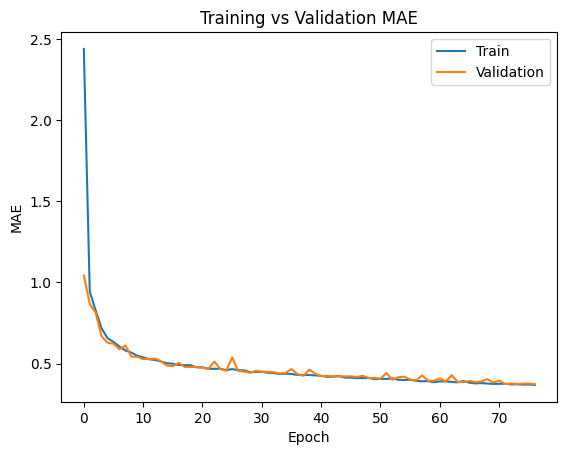

236/236 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step
========================= PLOT BREATH SAMPLES ON VALIDATION =========================


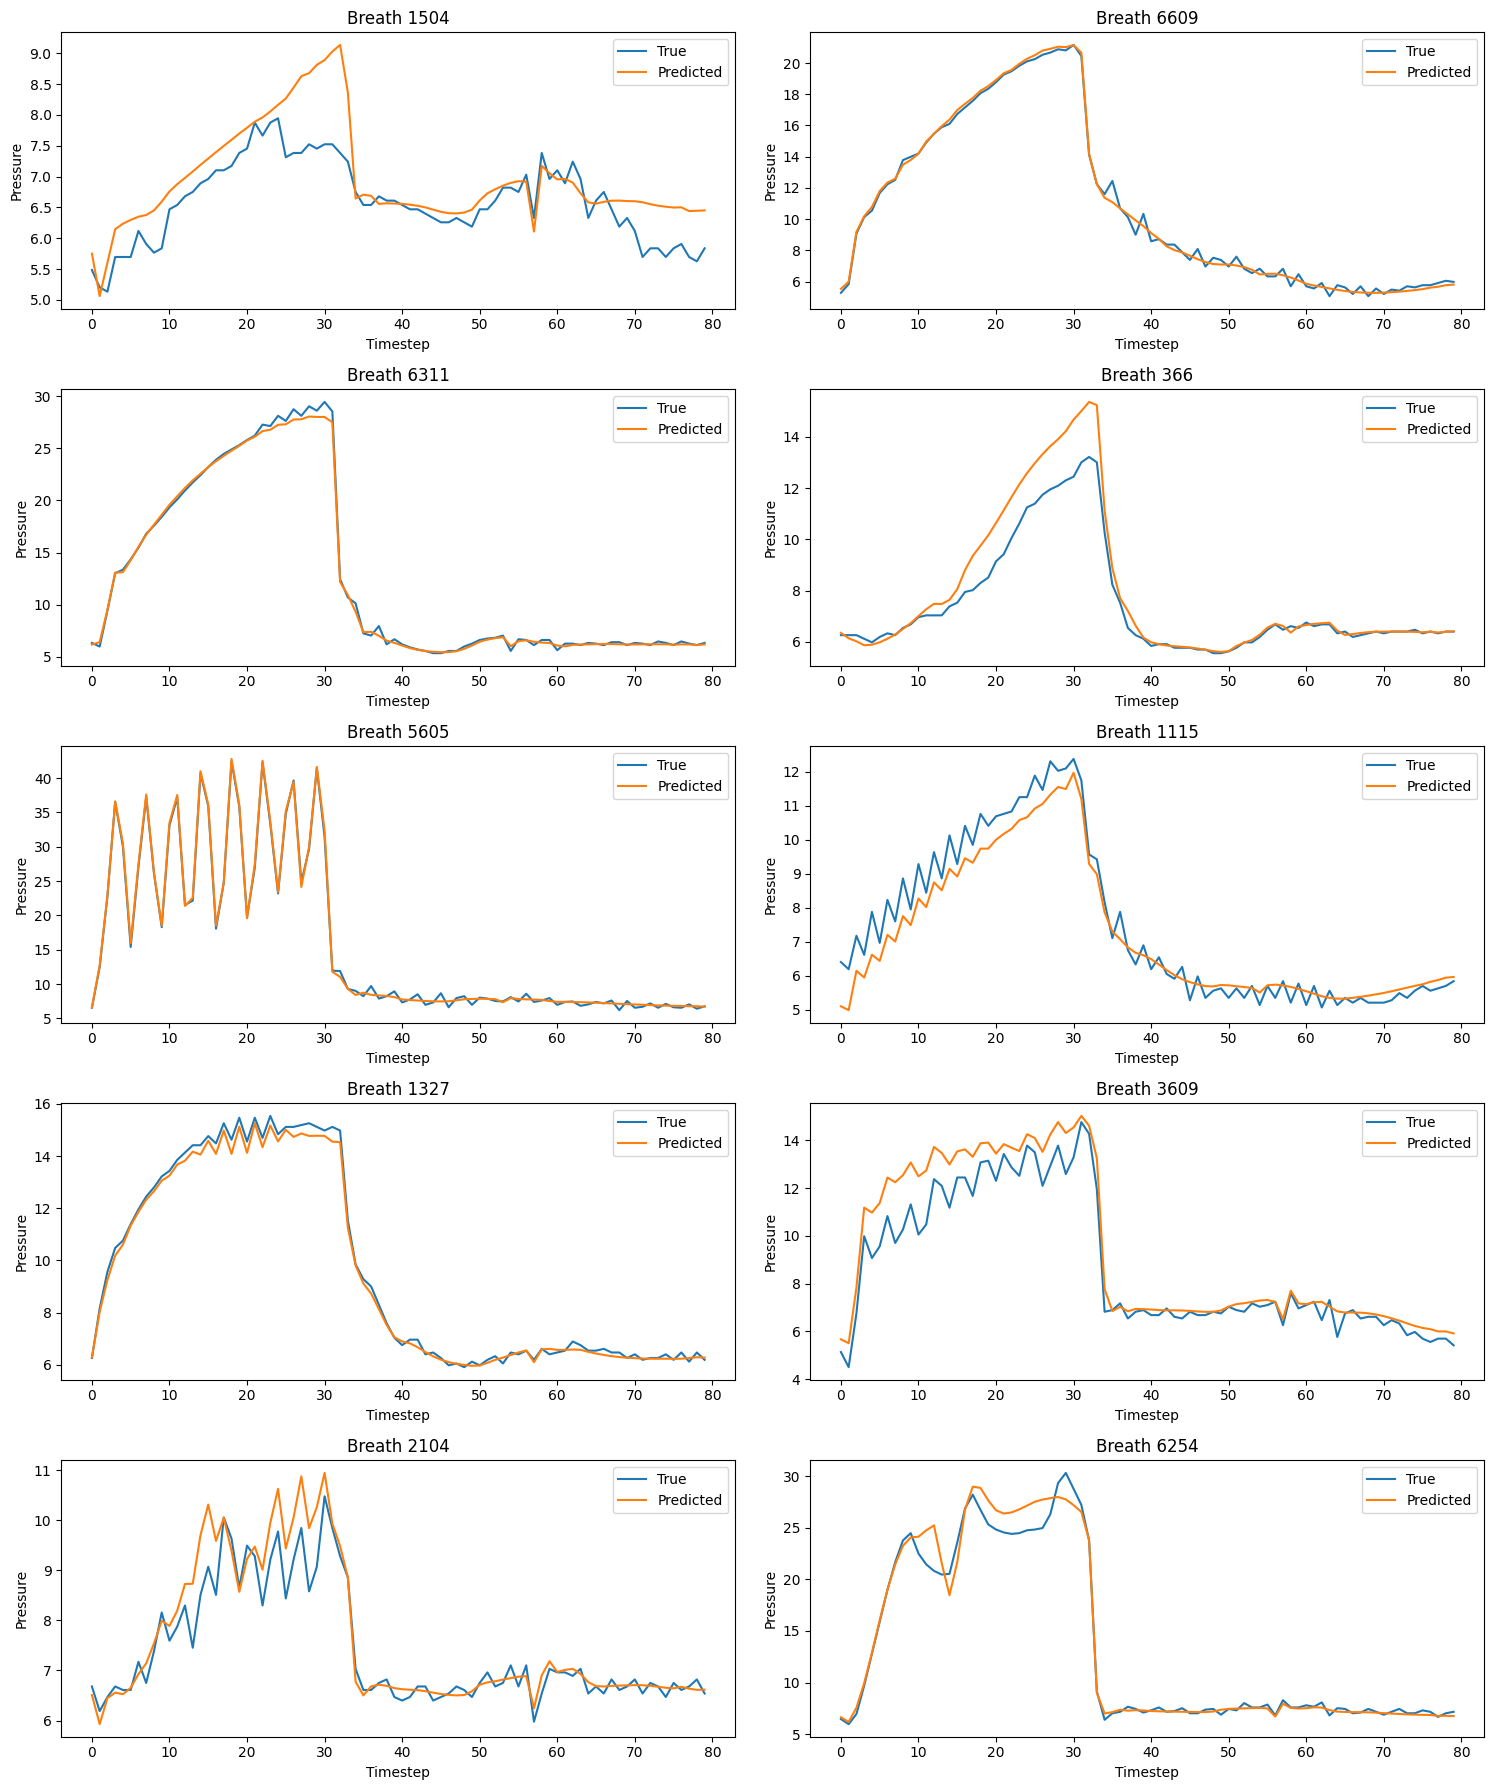

========================= PLOT BREATH SAMPLES ON TEST =========================
944/944 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step


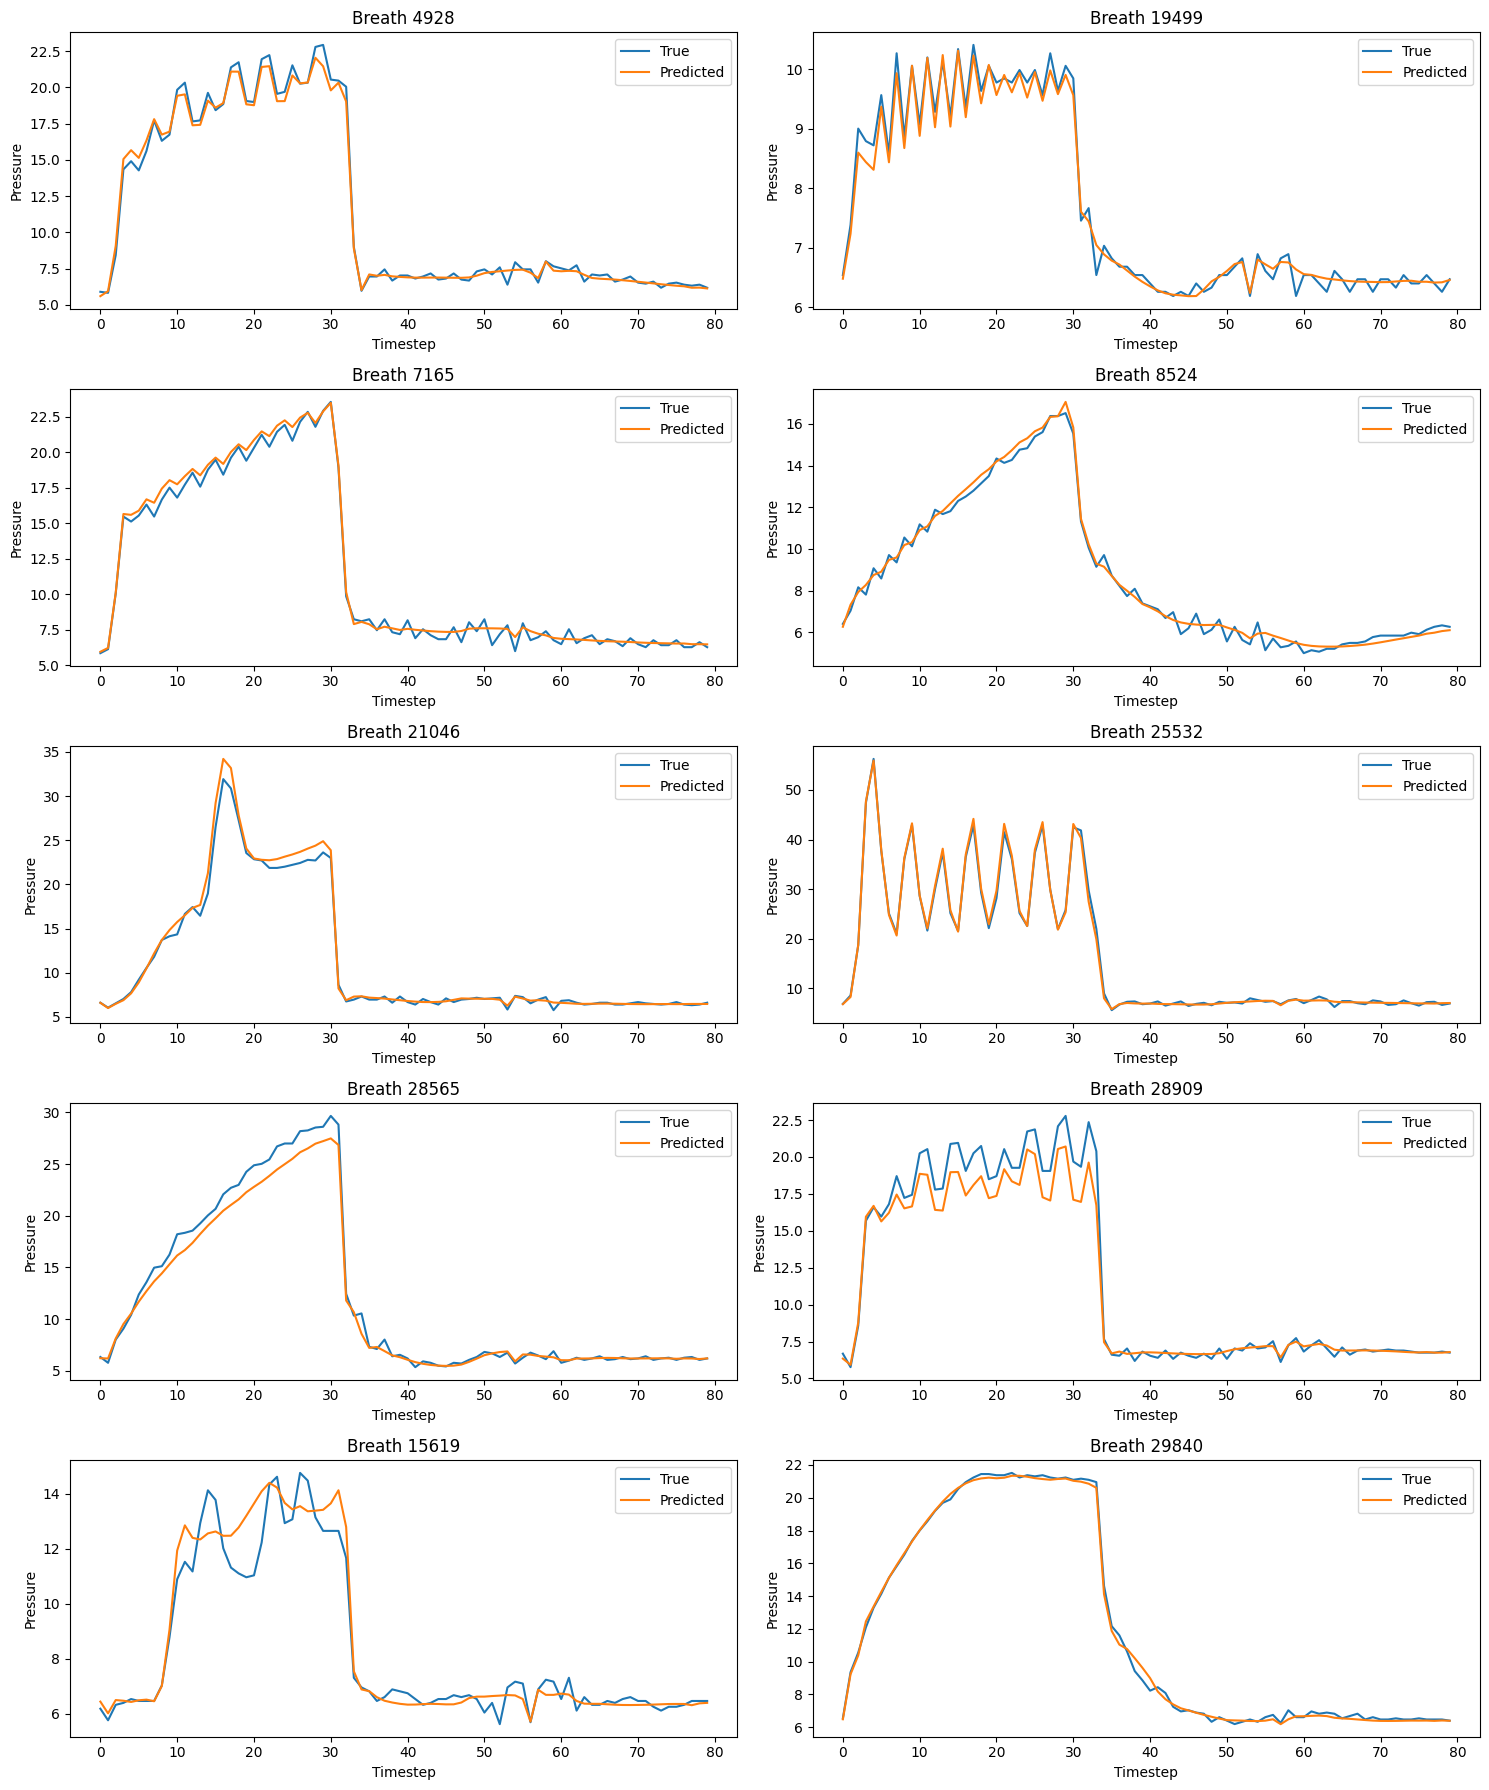

In [17]:

# --------------------------------------------------
# PLOT TRAINING HISTORY
# --------------------------------------------------
print('='*25,'PLOT TRAINING HISTORY','='*25)
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend(["Train", "Validation"])
plt.show()

# --------------------------------------------------
# PREDICTIONS on validation set
# --------------------------------------------------
y_pred = model.predict(val)
# --------------------------------------------------
# Plots of 10 single breath
# --------------------------------------------------
print('='*25,'PLOT BREATH SAMPLES ON VALIDATION','='*25)
num_samples = 10
indices = np.random.choice(len(y_val), num_samples, replace=False)

plt.figure(figsize=(15, 18))

for i, idx in enumerate(indices):
    plt.subplot(5, 2, i + 1)
    plt.plot(y_val[idx].flatten())
    plt.plot(y_pred[idx].flatten())
    plt.title(f"Breath {idx}")
    plt.xlabel("Timestep")
    plt.ylabel("Pressure")
    plt.legend(["True", "Predicted"])

plt.tight_layout()
plt.show()


# PREDICTIONS on validation set
# --------------------------------------------------
print('='*25,'PLOT BREATH SAMPLES ON TEST','='*25)
y_pred = model.predict(test)
# --------------------------------------------------
# Plots of 10 single breath
# --------------------------------------------------
num_samples = 10
indices = np.random.choice(len(y_test), num_samples, replace=False)

plt.figure(figsize=(15, 18))

for i, idx in enumerate(indices):
    plt.subplot(5, 2, i + 1)
    plt.plot(y_test[idx].flatten())
    plt.plot(y_pred[idx].flatten())
    plt.title(f"Breath {idx}")
    plt.xlabel("Timestep")
    plt.ylabel("Pressure")
    plt.legend(["True", "Predicted"])
plt.tight_layout()
plt.show()

# Retrain on all train set
 - We have tor ebuild the model and train with whole train dataset to a number of epochs close to the early stopping value

In [19]:

# --------------------------------------------------
# MODEL
# --------------------------------------------------
input_shape = train.shape[2]
model = Sequential()

model.add(Bidirectional(
    LSTM(80, return_sequences=True),
    input_shape=(80, input_shape)
))

model.add(Bidirectional(LSTM(80, return_sequences=True)))
model.add(Bidirectional(LSTM(80, return_sequences=True)))

model.add(TimeDistributed(Dense(80)))
model.add(LeakyReLU(negative_slope=0.1))

model.add(TimeDistributed(Dense(80)))
model.add(LeakyReLU(negative_slope=0.1))

model.add(TimeDistributed(Dense(1)))

model.add(Flatten())

# --------------------------------------------------
# COMPILE nd set optimizer
# --------------------------------------------------
batch_size = 128
epochs = 80
steps_per_epoch = len(train) // batch_size
total_steps = steps_per_epoch * epochs

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=total_steps,
    alpha=0.01
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='mae',
    metrics=['mae']
)

model.summary()

# --------------------------------------------------
# CALLBACKS
# --------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# --------------------------------------------------
# Train
# --------------------------------------------------
# Make new train set
X_full = np.concatenate([train, val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)

history = model.fit(
    X_full,
    y_full,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# --------------------------------------------------
# Save the model
# --------------------------------------------------
model.save('/ventilator_retrained.keras')


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 80, 160)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 80, 160)        │       154,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 80, 160)        │       154,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 80, 80)         │        12,880 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 80, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 80, 80)         │         6,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 80, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 80, 1)          │            81 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 80)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,161 (1.53 MB)

 Trainable params: 402,161 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - loss: 2.0339 - mae: 2.0339
Epoch 2/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - loss: 0.8955 - mae: 0.8955
Epoch 3/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - loss: 0.7511 - mae: 0.7511
Epoch 4/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - loss: 0.6747 - mae: 0.6747
Epoch 5/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - loss: 0.6394 - mae: 0.6394
Epoch 6/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - loss: 0.6107 - mae: 0.6107
Epoch 7/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - loss: 0.5856 - mae: 0.5856
Epoch 8/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - loss: 0.5626 - mae: 0.5626
Epoch 9/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - loss: 0.5476 - mae: 0.5476
Epoch 10/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - loss: 0.5297 - mae: 0.5297
Epoch 11/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - loss: 0.5190 - mae: 0.5190
Epoch 12/80
354/354 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - loss: 0.5121 - ma

# Plots

========================= PLOT BREATH SAMPLES ON TEST =========================
944/944 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step


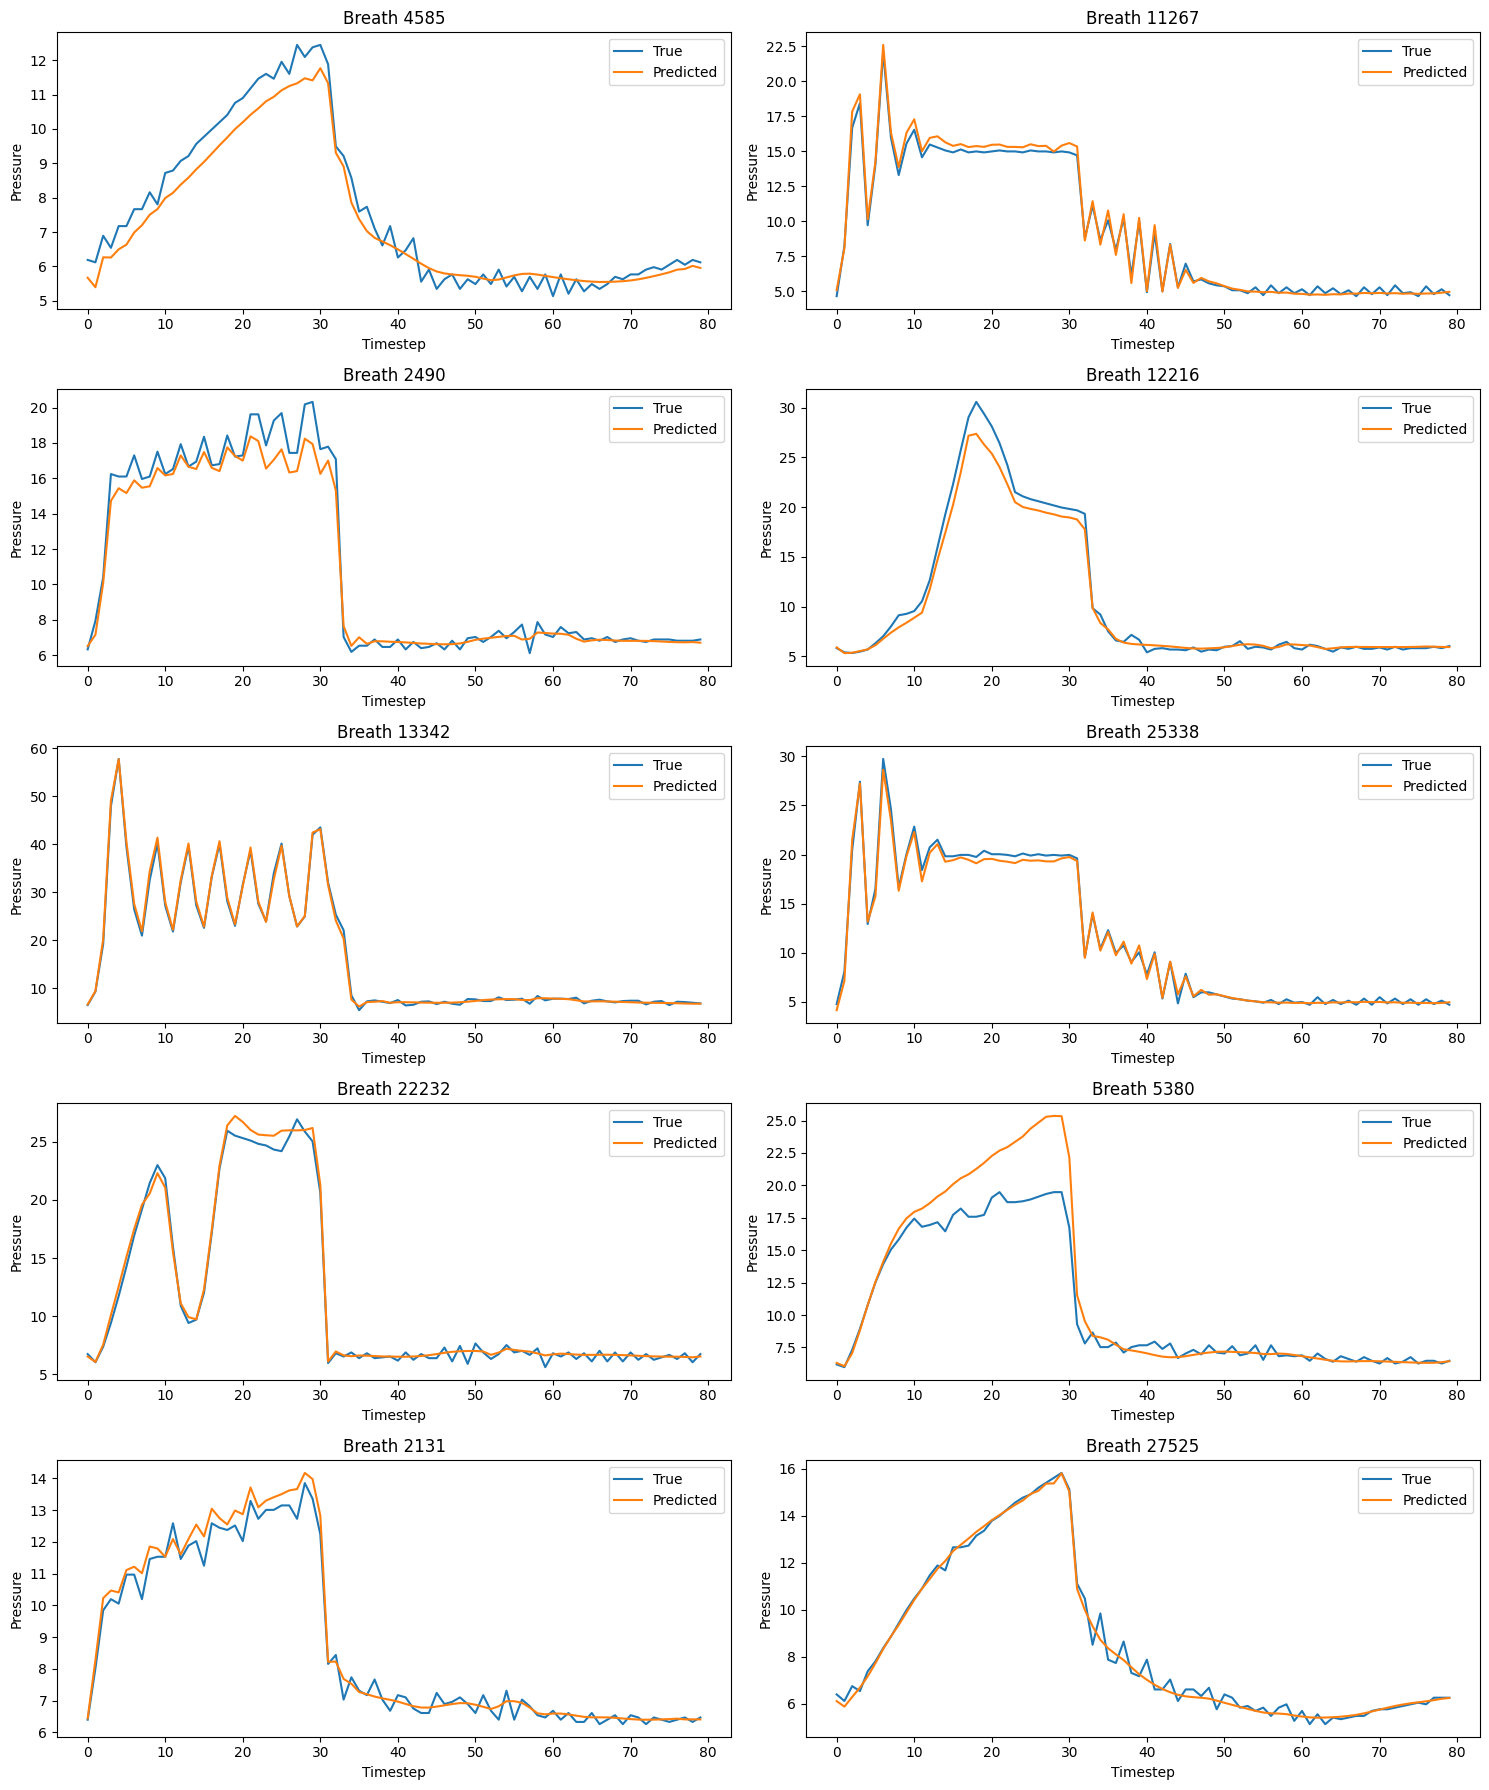

In [26]:
# PREDICTIONS on validation set
# --------------------------------------------------
print('='*25,'PLOT BREATH SAMPLES ON TEST','='*25)
y_pred = model.predict(test)
# --------------------------------------------------
# Plots of 10 single breath
# --------------------------------------------------
num_samples = 10
indices = np.random.choice(len(y_test), num_samples, replace=False)

plt.figure(figsize=(15, 18))

for i, idx in enumerate(indices):
    plt.subplot(5, 2, i + 1)
    plt.plot(y_test[idx].flatten())
    plt.plot(y_pred[idx].flatten())
    plt.title(f"Breath {idx}")
    plt.xlabel("Timestep")
    plt.ylabel("Pressure")
    plt.legend(["True", "Predicted"])
plt.tight_layout()
plt.show()

In [ ]:
#model.save('/content/drive/MyDrive/MAI/TXAI/ventilator_flatten_model.keras')

# SHAP

In [20]:
shap.initjs()

In [21]:
n_timesteps = train.shape[1]
n_features = train.shape[2]

train_flat = train.reshape(train.shape[0], -1)
test_flat = test.reshape(test.shape[0], -1)

def predict_fn(x):
    x = x.reshape(x.shape[0], n_timesteps, n_features)
    return model.predict(x)

print(train_flat.shape)

(37725, 2800)


In [23]:
background = train_flat[:10]

explainer = shap.KernelExplainer(predict_fn, background)

shap_values = explainer.shap_values(test_flat[:5])
shap_values = shap_values.reshape(-1, n_timesteps, n_features)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  0%|          | 0/5 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step


 20%|██        | 1/5 [01:16<05:06, 76.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1732/1732 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step


 40%|████      | 2/5 [02:28<03:41, 73.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step


 60%|██████    | 3/5 [03:34<02:20, 70.09s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step


 80%|████████  | 4/5 [04:40<01:08, 68.80s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step


100%|██████████| 5/5 [05:49<00:00, 69.94s/it]


## Shap Plots
What This Plot Represents  
- Y-axis: features used by the model  
- X-axis: SHAP value = impact on prediction  
- Each dot: one sample from the dataset  
- Distance from 0: strength of the feature’s influence  


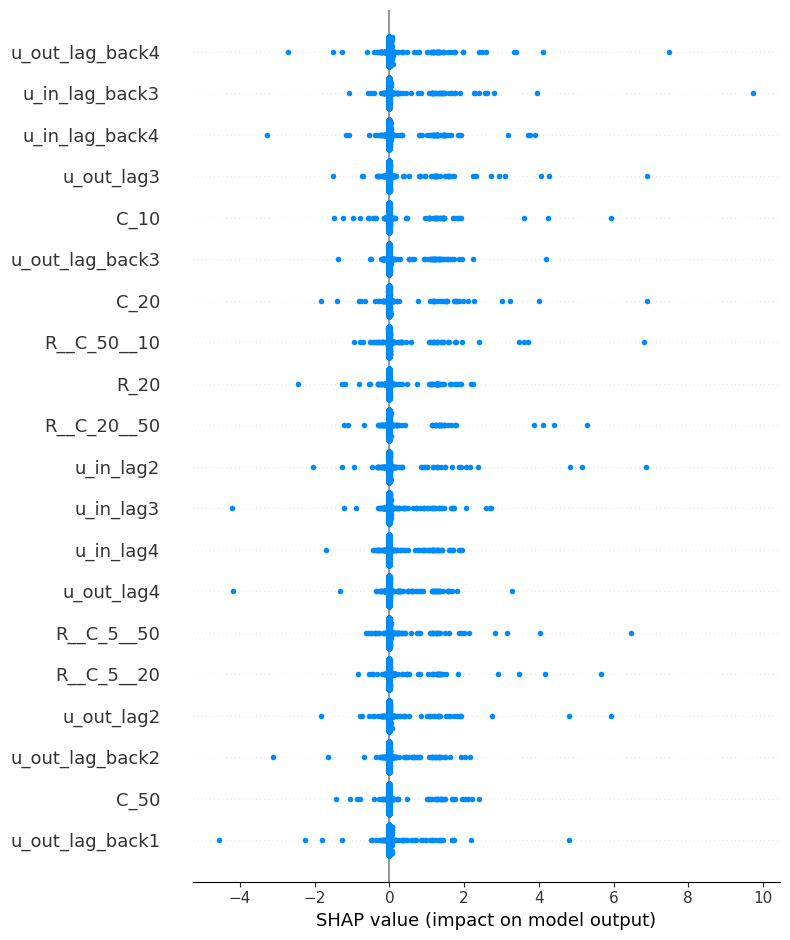

In [27]:
# flatten for summary plot: (samples*timesteps, features)
shap_flat = shap_values.reshape(-1, n_features)
shap.summary_plot(shap_flat, features=np.tile(features, shap_values.shape[0]*n_timesteps))

Interpretation:

- SHAP > 0 → pushes prediction higher  
- SHAP < 0 → pushes prediction lower  
- More spread → more important feature  

**Top contributors** appear to be:

- u_out_lag1
- u_in_lag3
- u_out_lag_back2
- u_out_lag_back1
- u_in_lag_back1
- u_in_lag2
- u_out_lag2

This tells us your LSTM heavily depends on recent past values.  
This is exactly what we expect in time-series dynamics.

**Medium Importance Features**  
These still influence predictions but less strongly:  
- R__C_20__50  
- R__C_50__50  
- R__C_5__50  
- R__C_50__10  
- R__C_5__10  
- area  

These are system configuration parameters, meaning the model uses them but dynamics dominate.

**Lowest Importance**  
- u_in_cumsum

This feature seems to contribute the least.  
Possible reasons:  
redundant with lag features  
LSTM already captures cumulative information internally  

**One Important Limitation of This Plot**

This SHAP plot collapses the time dimension.  
SHAP summarizes it only per feature, not per time step.  

A more informative plot would be:  
feature × timestep importance  
which shows **when** each feature matters.  

# SHAP Temporal Importance Heatmap

## Plot heatmap
This plot is a temporal SHAP heatmap, which shows how each feature influences the prediction at each timestep of our sequence.  

X-axis : Timestep (0–79)
Each column represents a time position in the sequence.  
Our model uses 80 timesteps.  

Y-axis : Features
- Examples:  
- u_in  
- u_out  
- lag features (u_in_lag1, u_out_lag2, etc.)  
- system parameters (R, C)  
- engineered features (area, u_in_cumsum)  

Color Meanings:  
| Color   | Meaning                          |
| ------- | -------------------------------- |
|  Red    | Feature **increases prediction** |
| Blue    | Feature **decreases prediction** |
| White   | Feature **little or no effect**  |



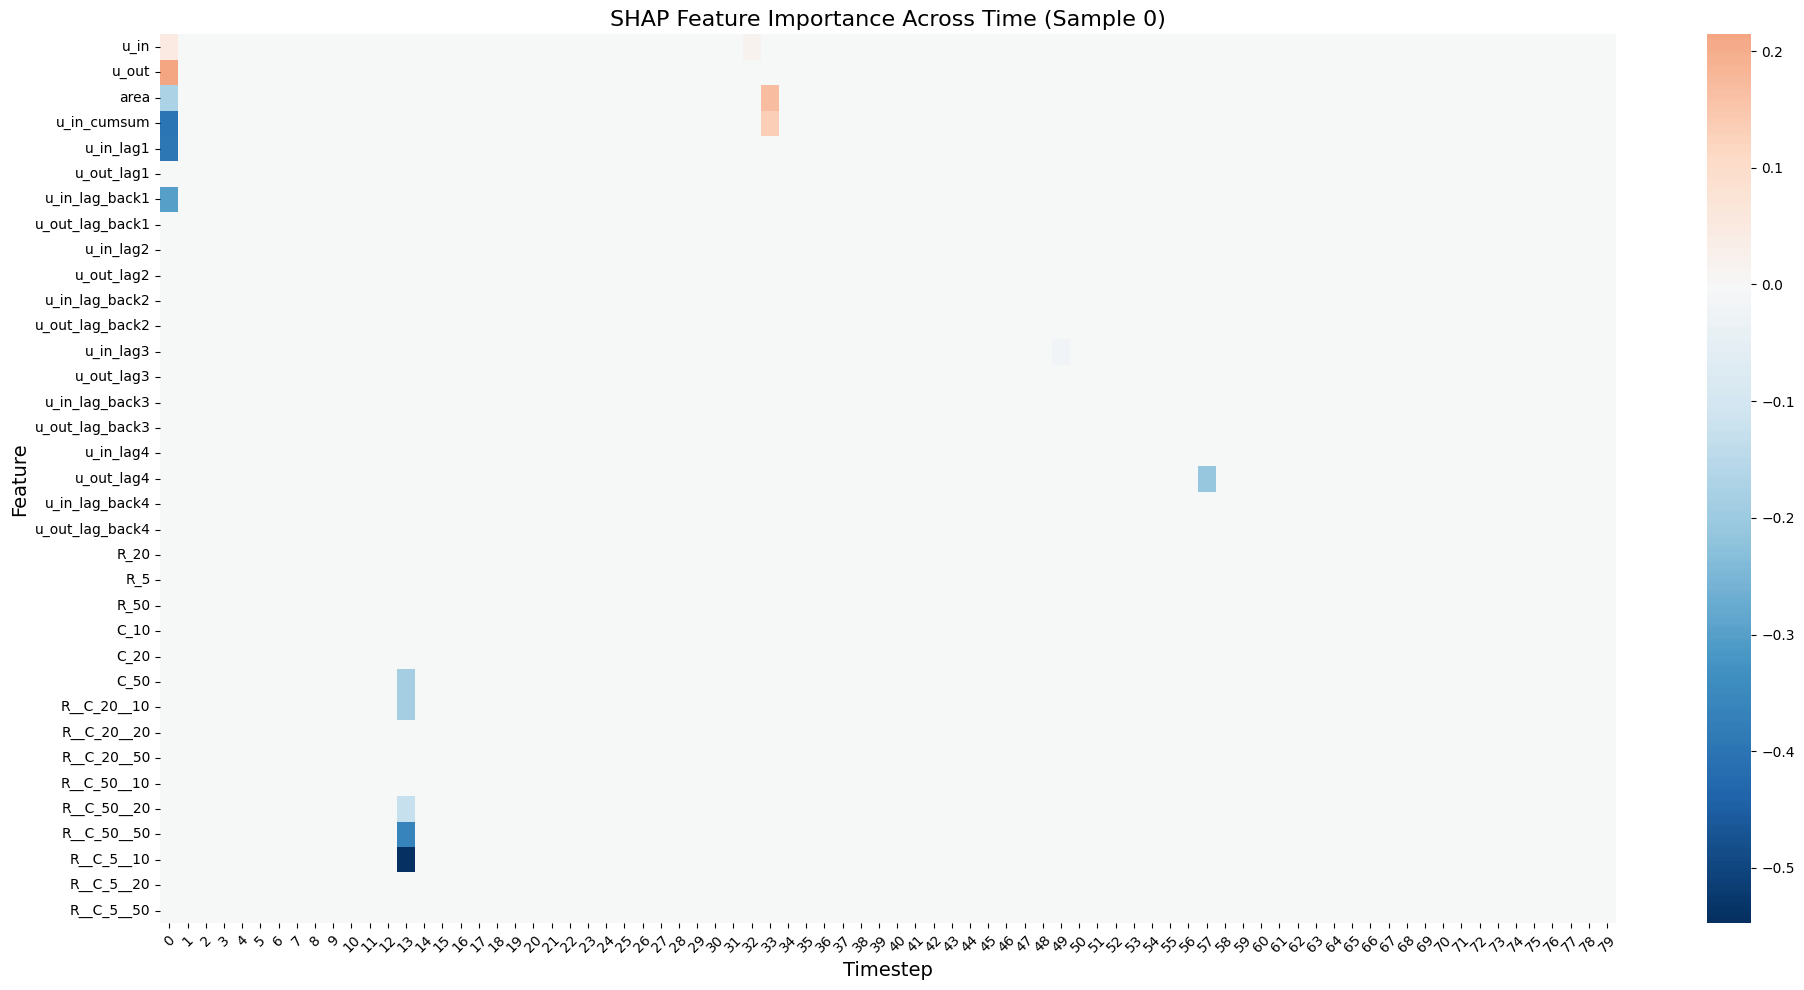

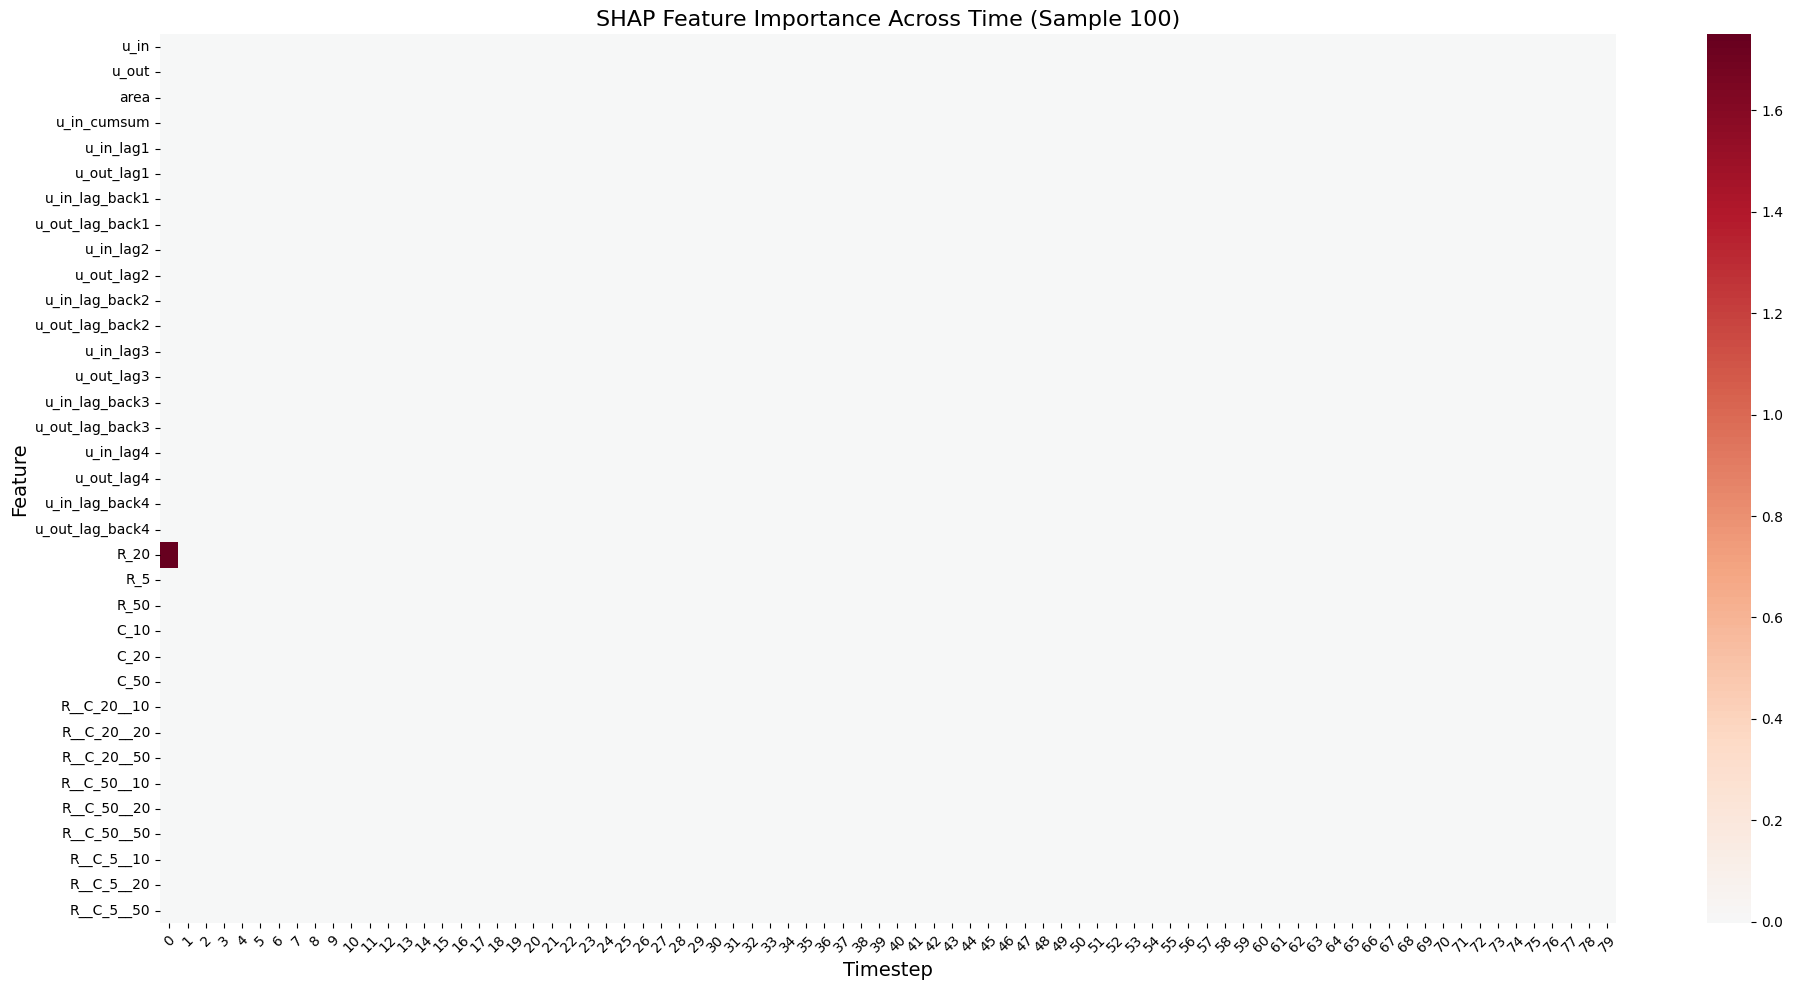

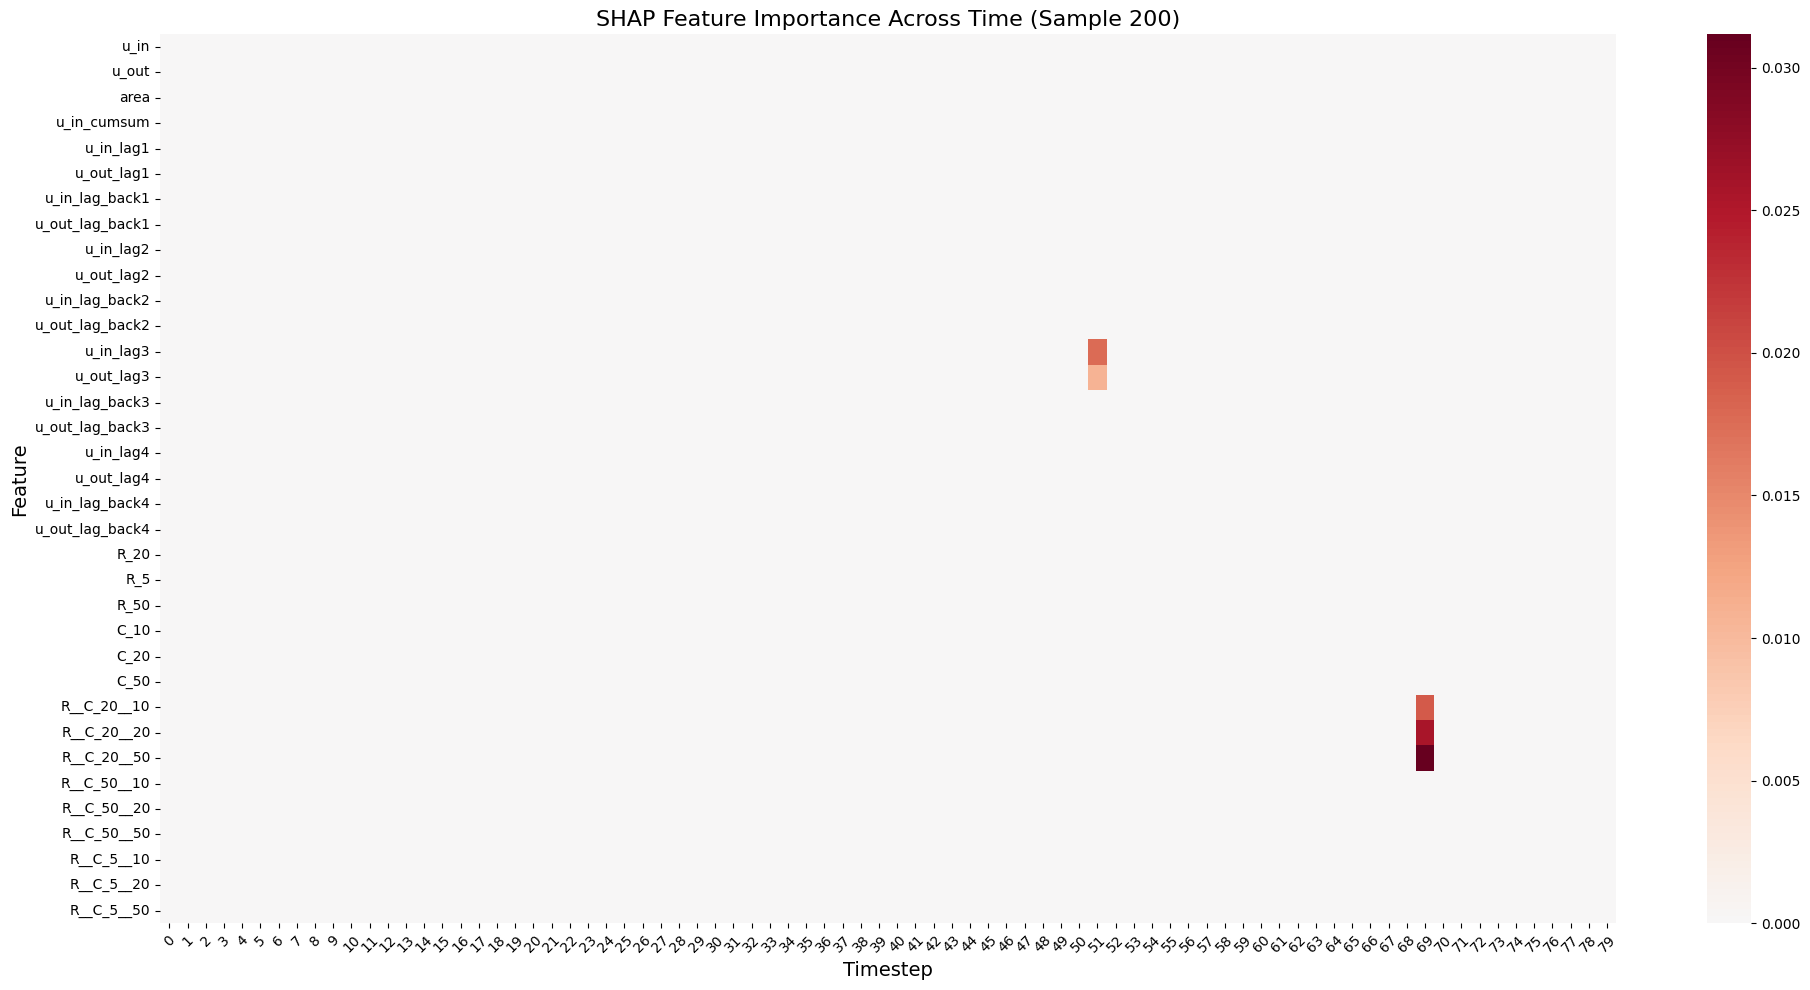

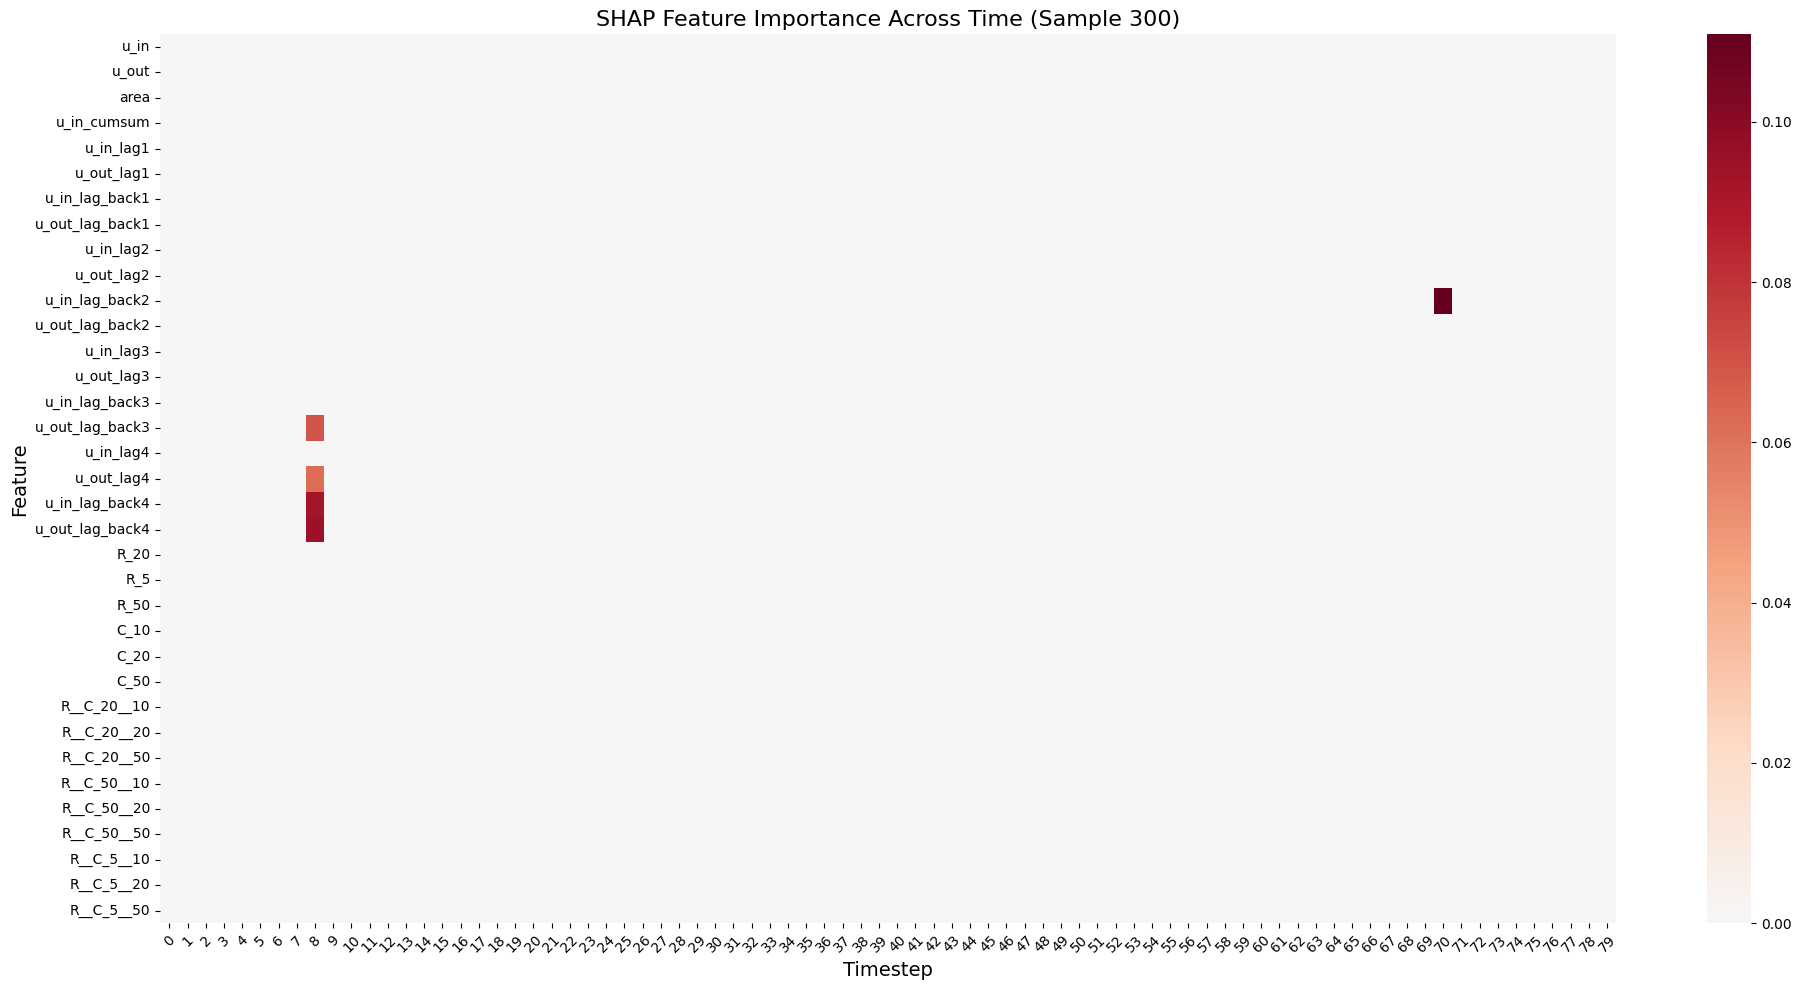

In [28]:
instances = [0, 100, 200, 300]

for instance in instances:
  plt.figure(figsize=(20, 10))  # width x height in inches
  sns.heatmap(
      shap_values[instance].T,
      xticklabels=range(n_timesteps),
      yticklabels=features,
      cmap="RdBu_r",
      center=0
  )

  plt.xlabel("Timestep", fontsize=14)
  plt.ylabel("Feature", fontsize=14)
  plt.title(f"SHAP Feature Importance Across Time (Sample {instance})", fontsize=16)
  plt.xticks(rotation=45)  # rotate x-axis labels for readability
  plt.yticks(rotation=0)   # keep y-axis labels horizontal
  plt.tight_layout()       # adjust layout to prevent cut-offs
  plt.show()

# Important Patterns in our Plot

Important timesteps appears to be:
t ≈ 24  
t ≈ 33  
t ≈ 50  
t ≈ 78  

Lag Features Are Dominant.  
System Parameters Affect Prediction Later.  

Early Timesteps Matter Less.  
We can notice how most of the left side of the plot is empty.
That means:  
t = 0–15  
has almost no influence on predictions.  

At timestep ~50:
many features turn blue  
which implies that they push predictions down  
That suggests a phase transition in the breathing cycle.  

Caveat:
SHAP plot shows local explanation, not global importance.
To see global feature-time importance we should run SHAP across all samples which a task very consuming time.
